# Attention & Transformers 



In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("torch:", torch.__version__)
print("device:", DEVICE)


torch: 2.14.0
device: mps


## 1. Why recurrence isn't the end of the story

 RNN → LSTM → GRU, and even the best of those — the gated ones — still have two problems that gates alone don't fix.

**Problem 1 — still sequential.** To compute the hidden state at word 50, an RNN/LSTM/GRU must first compute words 1 through 49, in order, one at a time. There's no way to parallelize across time steps within one sequence — training and inference both pay for every word, one after another, no matter how many GPU cores are sitting idle.

**Problem 2 — still a bottleneck, even with gates.** The measured result from Module 9 (RNN 68.2% vs. LSTM 70.45% vs. GRU 70.92% validation accuracy) shows gates genuinely help — but even LSTM/GRU still route *everything* the model has learned about the whole sentence through one fixed-size hidden state vector, updated step by step. For a very long sequence (a paragraph, a document), that single vector has to compress more and more, and something gets lost — the gates slow the forgetting, they don't eliminate the fundamental bottleneck of "one vector must summarize everything so far."

**The question that leads to attention:** what if, instead of forcing every word's influence to survive a long relay race through a single memory vector, the model could just... look directly at any earlier word it needs, whenever it needs it — no relay, no fading?

## 2. The big idea: attention — look directly, don't relay

Think back to the LSTM's "France ... French" example from Module 9. An LSTM has to write "France" onto its notepad and carry it, untouched, across every intervening word until "French" arrives. That works — but it depends entirely on the forget gate staying open for exactly that long.

**Attention skips the relay entirely.** When the model is processing the word "French," it can directly ask: "of all the words I've seen, which ones are relevant to me right now?" — and look straight at "France," six words back, with no notepad, no gate, no risk of the signal fading along the way. Every word gets to look at every other word, directly, in one step.

```mermaid
flowchart LR
    subgraph Recurrence [RNN / LSTM / GRU]
      direction LR
      w1["France"] --> w2["so"] --> w3["I"] --> w4["speak"] --> w5["fluent"] --> w6["French"]
    end
    subgraph Attn [Attention]
      direction TB
      a6["French"] -.->|"looks directly at"| a1["France"]
    end
```

That's the whole conceptual leap. Everything else in this notebook is the machinery for making "look directly at relevant words" into something a neural network can learn and compute efficiently.

## 3. Self-attention: Query, Key, Value

"Attention" needs a mechanism for deciding *which* earlier words are relevant to the current word, and *how much* to weight each one. The standard recipe borrows the vocabulary of a lookup system:

- **Query (Q)** — "what am I looking for?" A vector representing the current word's question.
- **Key (K)** — "what do I contain?" Every word (including the current one) advertises itself with a key.
- **Value (V)** — "what do I actually hand over if picked?" The content that gets returned if a word is deemed relevant.

Think of a dictionary lookup: you have a **query** (the word you're looking up), every dictionary entry has a **key** (the headword), and you retrieve the **value** (the definition) for whichever key best matches your query. Self-attention does this *softly* — instead of matching exactly one key, it computes how well the query matches **every** key, and blends **all** the values together, weighted by those match scores.

**Where Q, K, V actually come from:** each word's embedding gets multiplied by three separate learned weight matrices — `W_Q`, `W_K`, `W_V` — producing that word's query, key, and value vectors. Same embedding, three different learned projections, three different jobs.

```text
word embedding xᵢ  →  qᵢ = xᵢ·W_Q      (what I'm looking for)
                    →  kᵢ = xᵢ·W_K      (what I contain / how I'm found)
                    →  vᵢ = xᵢ·W_V      (what I hand over if relevant)
```

**A tiny worked example, by hand:** Suppose we have 3 words, each with a 4-dimensional query/key/value already computed (never mind exactly how — that's the matrix multiply above). We want to know: how much should word 3 ("French") attend to words 1 ("France"), 2 ("so"), and 3 ("French") itself?

In [2]:
torch.manual_seed(0)

words = ["France", "so", "French"]
d_k = 4  # dimensionality of each query/key vector

Q = torch.randn(3, d_k)  # one query per word
K = torch.randn(3, d_k)  # one key per word
V = torch.randn(3, d_k)  # one value per word

# Step 1: how well does word 3's QUERY match every word's KEY? (raw similarity scores)
scores = Q[2] @ K.T   # word 3's query, dotted with every word's key
print("raw scores (word 3 vs. each word's key):", scores.numpy().round(3))

# Step 2: turn scores into a probability distribution that sums to 1.
weights = F.softmax(scores, dim=0)
print("attention weights (sum to 1):          ", weights.numpy().round(3))

# Step 3: blend every word's VALUE, weighted by how much attention it got.
output = weights @ V
print("word 3's attention output:             ", output.numpy().round(3))
print("\n(compare to just using word 3's own value):", V[2].numpy().round(3))


raw scores (word 3 vs. each word's key): [ 0.834  0.514 -1.274]
attention weights (sum to 1):           [0.541 0.393 0.066]
word 3's attention output:              [ 0.108  0.437 -0.64  -0.927]

(compare to just using word 3's own value): [ 0.192  0.543 -2.219  0.259]


**What just happened, in plain words:** word 3 ("French") computed a similarity score against every word's key (including its own), turned those scores into weights that sum to 1 (softmax), then built its new representation as a weighted blend of every word's value. If "France" scored highest, its value dominates the blend — "French" effectively pulls in "France's" information, directly, in one step. No relay race through six time steps like an RNN would need.

## 4. Scaled dot-product attention — the actual formula

The hand-worked example above *is* attention, just missing one detail: a scaling factor.

```text
Attention(Q, K, V) = softmax( Q·Kᵀ / √d_k ) · V
```

**Why divide by `√d_k`:** the dot product `Q·Kᵀ` grows with the dimensionality `d_k` — more dimensions means larger dot products on average, purely from having more terms to sum, not because the match is genuinely stronger. Large raw scores push softmax into a very peaked, near-one-hot distribution (tiny gradients almost everywhere), which makes learning unstable. Dividing by `√d_k` keeps the scores in a range where softmax has healthy, usable gradients, regardless of how large `d_k` happens to be — a normalization detail, not a conceptual change.

In [3]:
def scaled_dot_product_attention(Q, K, V):
    d_k = Q.shape[-1]
    scores = Q @ K.transpose(-2, -1) / (d_k ** 0.5)
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

output_manual, weights_manual = scaled_dot_product_attention(Q, K, V)
print("manual scaled attention output for all 3 words:\n", output_manual.numpy().round(3))

output_torch = F.scaled_dot_product_attention(Q, K, V)
print("\ntorch.nn.functional.scaled_dot_product_attention:\n", output_torch.numpy().round(3))
print("\nmatch:", torch.allclose(output_manual, output_torch, atol=1e-5))


manual scaled attention output for all 3 words:
 [[ 0.117  0.451 -0.804 -0.806]
 [ 0.129  0.457 -1.049 -0.617]
 [ 0.109  0.382 -0.737 -0.827]]

torch.nn.functional.scaled_dot_product_attention:
 [[ 0.117  0.451 -0.804 -0.806]
 [ 0.129  0.457 -1.049 -0.617]
 [ 0.109  0.382 -0.737 -0.827]]

match: True


## 5. Multi-head attention — several ways of looking at once

One attention computation learns *one* notion of "relevant." But relevance can mean different things at once — "which word does this pronoun refer to," "which word does this verb's subject agree with," "which words share a topic." A single Q/K/V projection can't easily capture all of those simultaneously.

**The fix: run several attention computations in parallel, each with its own learned `W_Q`, `W_K`, `W_V`,** then concatenate their outputs and mix them back together with one more learned matrix.

```text
head₁ = Attention(Q·W_Q¹, K·W_K¹, V·W_V¹)
head₂ = Attention(Q·W_Q², K·W_K², V·W_V²)
   ...
headₕ = Attention(Q·W_Qʰ, K·W_Kʰ, V·W_Vʰ)

MultiHead(Q,K,V) = Concat(head₁, ..., headₕ) · W_O
```

Each head is free to specialize — one might learn to track subject-verb agreement, another might track coreference ("it" → the noun it refers to), without anyone hand-designing what each head should look for. This is *learned* specialization, discovered during training, not programmed in.

In [4]:
embed_dim = 16
num_heads = 4
seq_len = 5
batch_size = 2

mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

x = torch.randn(batch_size, seq_len, embed_dim)   # (batch, seq_len, embed_dim)

# Self-attention: the SAME tensor plays query, key, AND value -- every word looks at every
# other word IN THE SAME SEQUENCE (as opposed to "cross-attention," where query comes from
# one sequence and key/value come from another -- e.g. a decoder attending to an encoder).
attn_output, attn_weights = mha(query=x, key=x, value=x)

print("input shape:        ", tuple(x.shape), " <- (batch, seq_len, embed_dim)")
print("attn_output shape:  ", tuple(attn_output.shape), " <- same shape as input")
print("attn_weights shape: ", tuple(attn_weights.shape), " <- (batch, seq_len, seq_len): who attends to whom")


input shape:         (2, 5, 16)  <- (batch, seq_len, embed_dim)
attn_output shape:   (2, 5, 16)  <- same shape as input
attn_weights shape:  (2, 5, 5)  <- (batch, seq_len, seq_len): who attends to whom


**Reading the shapes:** `attn_weights` has shape `(batch, seq_len, seq_len)` — for every word (first `seq_len`), a full row of weights over every word it could attend to (second `seq_len`), summing to 1 per row, exactly like the hand-worked softmax example above, just batched. `attn_output` keeps the *same* shape as the input — attention doesn't change a sequence's shape, it only lets each position gather information from the others, which is exactly why Transformer blocks can be stacked.

## 6. Visualizing attention: who looks at whom

The clearest way to build intuition for attention weights is to actually look at them, on a real short sentence, as a heatmap.

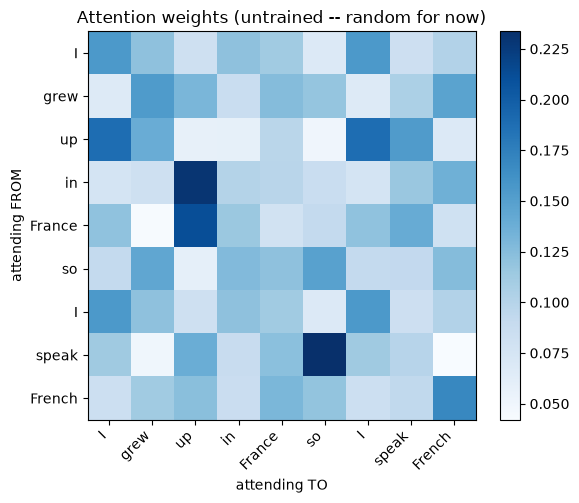

In [5]:
sentence = ["I", "grew", "up", "in", "France", "so", "I", "speak", "French"]
vocab = {w: i for i, w in enumerate(sorted(set(sentence)))}
ids = torch.tensor([[vocab[w] for w in sentence]])   # (1, seq_len)

torch.manual_seed(1)
toy_embedding = nn.Embedding(len(vocab), embed_dim)
toy_mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=1, batch_first=True)  # 1 head -> one clean picture

embedded = toy_embedding(ids)
_, weights = toy_mha(embedded, embedded, embedded)
weights = weights[0].detach().numpy()   # (seq_len, seq_len)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(weights, cmap="Blues")
ax.set_xticks(range(len(sentence))); ax.set_xticklabels(sentence, rotation=45, ha="right")
ax.set_yticks(range(len(sentence))); ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO"); ax.set_ylabel("attending FROM")
plt.colorbar(im); plt.title("Attention weights (untrained -- random for now)")
plt.tight_layout(); plt.show()


## 7. Positional encoding — attention has no sense of order

Here's a real gap attention introduces that RNNs never had: an RNN reads word 1 before word 2 by *construction* — order is baked into the recurrence. Attention has no such thing built in — the formula `softmax(Q·Kᵀ/√d_k)·V` would compute the exact same result if you shuffled the words, as long as you shuffled Q, K, and V consistently. Attention is **permutation-equivariant**: it doesn't know "France" came before "French" unless something tells it.

**The fix: add a position-dependent vector to each word's embedding before attention ever sees it.** The original Transformer paper used fixed sine/cosine functions of the position:

```text
PE(pos, 2i)   = sin( pos / 10000^(2i/d) )
PE(pos, 2i+1) = cos( pos / 10000^(2i/d) )
```

**Why sine/cosine specifically, not just the raw position number:** using the raw integer `0, 1, 2, ...` directly would make position values grow unboundedly for long sequences, and a position like `500` would look nothing like `501` in scale. Sine/cosine waves stay bounded between -1 and 1 regardless of sequence length, and — because of the trigonometric identity for `sin(a+b)`/`cos(a+b)` — the encoding for position `pos+k` can be written as a *linear function* of the encoding for position `pos`, which makes it easy for the model to learn to attend by *relative* position ("the word 3 positions back"), not just absolute position.

positional encoding shape: (50, 32)  <- (seq_len, d_model), added directly to word embeddings


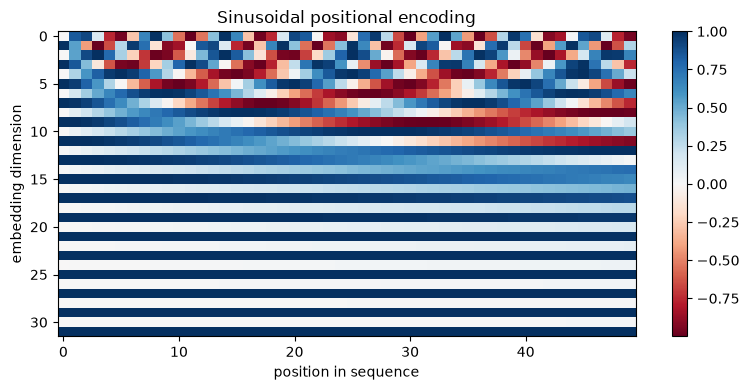

In [6]:
def positional_encoding(seq_len, d_model):
    pos = torch.arange(seq_len).unsqueeze(1).float()
    i = torch.arange(d_model).unsqueeze(0).float()
    angle_rates = 1 / (10000 ** (2 * (i // 2) / d_model))
    angles = pos * angle_rates
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(angles[:, 0::2])
    pe[:, 1::2] = torch.cos(angles[:, 1::2])
    return pe

pe = positional_encoding(seq_len=50, d_model=32)
print("positional encoding shape:", tuple(pe.shape), " <- (seq_len, d_model), added directly to word embeddings")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(pe.numpy().T, cmap="RdBu", aspect="auto")
ax.set_xlabel("position in sequence"); ax.set_ylabel("embedding dimension")
plt.colorbar(im); plt.title("Sinusoidal positional encoding")
plt.tight_layout(); plt.show()


**One more practical fact worth naming:** not every modern Transformer uses this exact sinusoidal scheme — many (including BERT) instead *learn* a positional embedding the same way they learn word embeddings (a lookup table trained end to end). The concept — "inject position information additively, since attention itself has none" — is what matters; the specific formula is one implementation choice among several.

## 8. The Transformer block: attention is only half of it

A full Transformer layer is not just attention — it's attention plus a few supporting pieces that make deep stacks trainable, echoing ideas from earlier in this course.

```mermaid
flowchart TB
    IN["input embeddings<br/>(+ positional encoding)"] --> MHA["Multi-Head<br/>Self-Attention"]
    MHA --> ADD1["Add & Norm<br/>(residual connection)"]
    IN --> ADD1
    ADD1 --> FFN["Feed-Forward<br/>Network (2 linear layers)"]
    FFN --> ADD2["Add & Norm<br/>(residual connection)"]
    ADD1 --> ADD2
    ADD2 --> OUT["output<br/>(same shape as input)"]
```

- **Multi-head self-attention** — the mechanism from Section 5: every position gathers information from every other position.
- **Residual connections ("Add")** — the output is added back to its own input, not just replaced by it. This is the *exact same idea* as ResNet's skip connections from the vision modules: it gives gradients a direct path backward through a deep stack of layers, the same "gradient highway" principle as LSTM's additive cell-state update from Module 9, applied here to depth instead of time.
- **Layer normalization ("Norm")** — normalizes activations so training stays stable as you stack many of these blocks — a different normalization than BatchNorm (it normalizes across each example's own features, not across the batch), chosen because sequence lengths vary and batch statistics get noisy for text.
- **Feed-forward network** — a small 2-layer MLP applied independently to *each* position — after attention has mixed information *across* positions, this lets the model process each position's *own* combined representation further.

**Stack several of these blocks** — the original Transformer used 6, BERT-base uses 12, larger models use dozens — and each layer lets positions gather progressively more abstract, longer-range information, entirely in parallel across the sequence, unlike an RNN's forced one-step-at-a-time march.

### Encoder vs. decoder — where BERT and GPT diverge

The word "Transformer" covers two different uses of this same block:

| | Self-attention direction | Typical use | Examples |
|---|---|---|---|
| **Encoder** | bidirectional — every word sees every word, including future ones | understanding a full, already-complete piece of text | BERT, our fine-tuning task below |
| **Decoder** | causal / masked — a word can only see itself and earlier words | generating text one token at a time | GPT family |

**Why this matters for the fine-tuning below:** classification tasks like sentiment analysis have the *entire* review available at once — there's no reason to hide future words from the model, so an **encoder** (bidirectional) architecture like BERT is the natural fit. Text generation genuinely can't look at words it hasn't generated yet, which is why GPT-style models mask future positions during self-attention (a "causal mask") — a word's query is only allowed to match keys at its own position or earlier.

## 9. From building blocks to a pretrained model

Everything above explains the *mechanism*. In practice, nobody trains a Transformer from scratch for a task like sentiment classification — that takes billions of words and enormous compute. Instead:

```text
1. Someone else pretrains a large Transformer on a huge, general text corpus
   (predicting masked/next words -- no labels needed, "self-supervised")
2. You download those pretrained weights
3. You FINE-TUNE the pretrained model on your small, labeled dataset
   (a few epochs -- the model already understands language; it just needs to
    learn YOUR specific task on top of that)
```

This is the exact same transfer-learning idea from the vision modules — pretrained ResNet/EfficientNet on ImageNet, then fine-tuned on a small task-specific dataset — just for text instead of images, and using Transformers instead of CNNs.

**`distilbert-base-uncased`** is what we'll fine-tune: a smaller, distilled version of BERT (about 40% fewer parameters, ~97% of BERT's language understanding, notably faster) — a sensible default for a first fine-tuning exercise, the same reasoning that picked ResNet18 over bigger backbones for an easy vision task in Module 8.

In [7]:
!pip install -q transformers

from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

sample = "This movie was surprisingly good."
encoded = tokenizer(sample, return_tensors="pt")
print("input_ids:     ", encoded["input_ids"])
print("decoded back:  ", tokenizer.convert_ids_to_tokens(encoded["input_ids"][0]))


input_ids:      tensor([[  101,  2023,  3185,  2001, 10889,  2204,  1012,   102]])
decoded back:   ['[CLS]', 'this', 'movie', 'was', 'surprisingly', 'good', '.', '[SEP]']


## 10. Fine-tuning DistilBERT on the same dataset as Module 9

Same dataset, same task, same train/val/test split logic as Module 9's mini-project — the only thing changing is the architecture. That's what makes the comparison fair.

In [8]:
from datasets import load_dataset

raw = load_dataset("cornell-movie-review-data/rotten_tomatoes")
print(raw)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})


In [9]:
MAX_LEN = 64

def tokenize_batch(batch):
    return tokenizer(batch["text"], padding="max_length", truncation=True, max_length=MAX_LEN)

tokenized = raw.map(tokenize_batch, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(tokenized)
print("\none example input_ids shape:", tokenized["train"][0]["input_ids"].shape, " <- (MAX_LEN,)")



Map:   0%|          | 0/8530 [00:00<?, ? examples/s]


Map:  70%|███████   | 6000/8530 [00:00<00:00, 54189.86 examples/s]


Map: 100%|██████████| 8530/8530 [00:00<00:00, 53861.93 examples/s]


Map:   0%|          | 0/1066 [00:00<?, ? examples/s]


Map: 100%|██████████| 1066/1066 [00:00<00:00, 46902.08 examples/s]


Map:   0%|          | 0/1066 [00:00<?, ? examples/s]


Map: 100%|██████████| 1066/1066 [00:00<00:00, 50665.49 examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1066
    })
})

one example input_ids shape: torch.Size([64])  <- (MAX_LEN,)


In [10]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16
train_loader = DataLoader(tokenized["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(tokenized["validation"], batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(tokenized["test"], batch_size=BATCH_SIZE, shuffle=False)

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)   # small LR -- protect pretrained weights,
                                                               # same "nudge, don't overwrite" principle as
                                                               # Module 8's fine-tuning learning rates
EPOCHS = 2
print(f"trainable parameters: {sum(p.numel() for p in model.parameters()):,}")



Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 14275.57it/s]


[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


trainable parameters: 66,955,010


In [11]:
def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, n = 0.0, 0, 0
    torch.set_grad_enabled(is_train)
    for batch in loader:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["label"].to(DEVICE)

        if is_train:
            optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        if is_train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * input_ids.size(0)
        correct += (outputs.logits.argmax(1) == labels).sum().item()
        n += input_ids.size(0)
    torch.set_grad_enabled(True)
    return total_loss / n, correct / n

history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    print(f"epoch {epoch}/{EPOCHS} | train loss {train_loss:.4f} acc {train_acc:.4f} | val loss {val_loss:.4f} acc {val_acc:.4f}")


epoch 1/2 | train loss 0.4148 acc 0.8134 | val loss 0.3320 acc 0.8527


epoch 2/2 | train loss 0.2257 acc 0.9158 | val loss 0.3867 acc 0.8340


## 11. The payoff: comparing against Module 9's RNN/LSTM/GRU

Same dataset, same task, same held-out split. Here's the direct comparison.

DistilBERT TEST accuracy: 0.8330


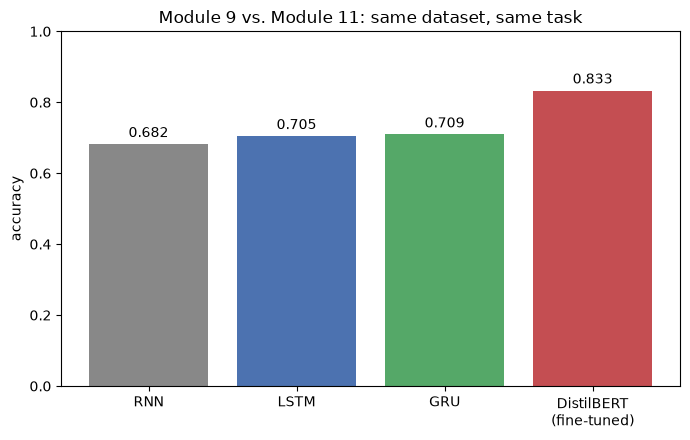

In [12]:
test_loss, test_acc = run_epoch(model, test_loader)
print(f"DistilBERT TEST accuracy: {test_acc:.4f}")

names = ["RNN", "LSTM", "GRU", "DistilBERT\n(fine-tuned)"]
accs = [0.6820, 0.7045, 0.7092, test_acc]   # RNN/LSTM/GRU numbers measured in Module 9

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(names, accs, color=["#888", "#4c72b0", "#55a868", "#c44e52"])
ax.set_ylabel("accuracy"); ax.set_ylim(0, 1); ax.set_title("Module 9 vs. Module 11: same dataset, same task")
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.3f}", ha="center")
plt.tight_layout(); plt.show()


## 12. The same honesty check as Module 9

Module 9's LSTM confidently generalized phrase-level sentiment but did **not** reliably flip on the literal word "not." Let's run DistilBERT through the exact same sentences.

In [13]:
@torch.no_grad()
def predict_sentiment(model, tokenizer, sentence):
    model.eval()
    encoded = tokenizer(sentence, return_tensors="pt", padding="max_length", truncation=True, max_length=MAX_LEN).to(DEVICE)
    logits = model(**encoded).logits[0]
    probs = torch.softmax(logits, dim=0)
    label = "POSITIVE" if probs[1] > probs[0] else "NEGATIVE"
    return label, probs.max().item()

test_sentences = [
    "smart, funny, and surprisingly touching",
    "dumb, unfunny, and surprisingly boring",
    "an ambitious film that ultimately delivers on its promise",
    "an ambitious film that ultimately fails to deliver on its promise",
    "the movie was excellent",
    "the movie was not excellent",
    "this film was a total waste of time",
    "this film was not a total waste of time",
]

for sentence in test_sentences:
    label, confidence = predict_sentiment(model, tokenizer, sentence)
    print(f"{sentence!r:65s} -> {label:8s} ({confidence:.0%})")


'smart, funny, and surprisingly touching'                         -> POSITIVE (99%)
'dumb, unfunny, and surprisingly boring'                          -> NEGATIVE (98%)
'an ambitious film that ultimately delivers on its promise'       -> POSITIVE (99%)
'an ambitious film that ultimately fails to deliver on its promise' -> NEGATIVE (96%)
'the movie was excellent'                                         -> POSITIVE (98%)
'the movie was not excellent'                                     -> NEGATIVE (96%)
'this film was a total waste of time'                             -> NEGATIVE (99%)
'this film was not a total waste of time'                         -> NEGATIVE (80%)
